# 04 — Offline evaluation (1-min single model)

Diagnostics on the predictions cache produced by `03_train_model.ipynb`.

Sections:
1. Headline metrics with block-bootstrap CIs (block_size = M = 20)
2. ROC and PR curves with bootstrap bands
3. Calibration curve + reliability diagram
4. Score distribution by class and split
5. Threshold sweep: precision / Net-EV vs threshold (using `r_realized`
   augmentation from `src.strategy.cache`)
6. Rolling metrics over time — degradation diagnostic
7. Causal feature audit on the production feature list
8. Virtual-ensemble uncertainty diagnostics

Reads:
- `data/model_dataset/research_predictions_1min.parquet`
- `data/model_dataset/analytics/train_scores_unc_1min.parquet`
- `data/model_dataset/analytics/val_test_ve_unc_1min.parquet`
- `data/model_dataset/predictions_metadata_1min.json`
- `data/model_dataset/dataset_metadata_1min.json`
- `data/model_dataset/analytics/research_metrics_1min.json`
- `data/raw_data/klines_1m.parquet`

Writes:
- `data/model_dataset/analytics/offline_evaluation_1min.json`
- `data/model_dataset/plots/offline_*.png`


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
    if (ROOT.parent / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError('Could not locate repo root.')
sys.path.insert(0, str(ROOT))

from sklearn.metrics import (
    average_precision_score, brier_score_loss, log_loss, roc_auc_score,
)

from src import utils
from src.analytics.audits import causal_feature_audit
from src.analytics.bootstrap import bootstrap_metric
from src.analytics.curves import (
    bootstrap_calibration_curve, bootstrap_pr_curve, bootstrap_roc_curve,
)
from src.analytics.degradation import rolling_metrics_with_ci
from src.features.config import M, PHI
from src.strategy.baseline import COST_PER_TRADE
from src.strategy.cache import augment_cache_with_r_realized

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160, 'font.size': 9,
    'axes.titlesize': 10, 'axes.titleweight': 'bold',
    'axes.labelsize': 9, 'legend.fontsize': 8,
    'axes.grid': True, 'grid.alpha': 0.25,
})

DATASET_DIR = ROOT / 'data' / 'model_dataset'
CACHE_PATH = DATASET_DIR / 'research_predictions_1min.parquet'
TRAIN_UNC_PATH = DATASET_DIR / 'analytics' / 'train_scores_unc_1min.parquet'
VAL_TEST_UNC_PATH = DATASET_DIR / 'analytics' / 'val_test_ve_unc_1min.parquet'
PRED_META_PATH = DATASET_DIR / 'predictions_metadata_1min.json'
DATASET_META_PATH = DATASET_DIR / 'dataset_metadata_1min.json'
RESEARCH_METRICS_PATH = DATASET_DIR / 'analytics' / 'research_metrics_1min.json'
RAW_PATH = ROOT / 'data' / 'raw_data' / 'klines_1m.parquet'
FEATURE_LIST_PATH = DATASET_DIR / 'feature_list_1min.json'

PLOTS_DIR = DATASET_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYTICS_DIR = DATASET_DIR / 'analytics'
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)
OFFLINE_OUT = ANALYTICS_DIR / 'offline_evaluation_1min.json'

BOOTSTRAP_BLOCK = int(M)
B_BOOTSTRAP = 500

print(f'ROOT      : {ROOT}')
print(f'M, PHI    : {M}, {PHI}')
print(f'block size: {BOOTSTRAP_BLOCK}  (B={B_BOOTSTRAP})')

ROOT      : C:\Users\vitil\OneDrive\Desktop\barrier_classifier
M, PHI    : 20, 0.0025
block size: 20  (B=500)


## 1. Load predictions cache + metadata

In [2]:
cache = pd.read_parquet(CACHE_PATH)
train_unc = pd.read_parquet(TRAIN_UNC_PATH)
val_test_unc = pd.read_parquet(VAL_TEST_UNC_PATH)

with open(PRED_META_PATH) as f:
    pred_meta = json.load(f)
with open(DATASET_META_PATH) as f:
    ds_meta = json.load(f)
with open(RESEARCH_METRICS_PATH) as f:
    research_metrics = json.load(f)
feature_list = utils.load_json(FEATURE_LIST_PATH)

# Augment cache with realized M-bar log return (used for Net-EV).
raw = pd.read_parquet(RAW_PATH, columns=['open', 'high', 'low', 'close'])
cache = augment_cache_with_r_realized(cache, raw, M=int(M))

# Join VE uncertainty by (k, split).
cache = cache.merge(val_test_unc, on=['k', 'split'], how='left')

print(f'Cache       : {len(cache):,} rows  splits={cache["split"].value_counts().to_dict()}')
print(f'Train unc   : {len(train_unc):,} rows  p_train range '
      f'[{train_unc["p_train"].min():.4f}, {train_unc["p_train"].max():.4f}]')
print(f'Knowledge_unc range (train) : '
      f'[{train_unc["knowledge_unc_train"].min():.6f}, '
      f'{train_unc["knowledge_unc_train"].max():.6f}]')
print(f'Knowledge_unc median (train): '
      f'{float(train_unc["knowledge_unc_train"].median()):.6f}')

val = cache[cache['split'] == 'val'].reset_index(drop=True)
test = cache[cache['split'] == 'test'].reset_index(drop=True)
print(f'val : n={len(val):,}  base_rate={val["y"].mean():.4f}')
print(f'test: n={len(test):,}  base_rate={test["y"].mean():.4f}')

Cache       : 149,227 rows  splits={'test': 74614, 'val': 74613}
Train unc   : 353,794 rows  p_train range [0.0057, 0.9583]
Knowledge_unc range (train) : [0.000000, 0.325083]
Knowledge_unc median (train): 0.000000
val : n=74,613  base_rate=0.1900
test: n=74,614  base_rate=0.2521


## 2. Headline metrics — block-bootstrap CIs

In [3]:
def _headline(y, p):
    metrics = {}
    for mn, fn in [
        ('roc_auc',  lambda yy, pp: float(roc_auc_score(yy, pp))),
        ('pr_auc',   lambda yy, pp: float(average_precision_score(yy, pp))),
        ('log_loss', lambda yy, pp: float(log_loss(yy, pp, labels=[0, 1]))),
        ('brier',    lambda yy, pp: float(brier_score_loss(yy, pp))),
    ]:
        res = bootstrap_metric(
            fn, y.astype(int).to_numpy(), p.astype(float).to_numpy(),
            B=B_BOOTSTRAP, stratify=False, seed=0, block_size=BOOTSTRAP_BLOCK,
        )
        metrics[mn] = {
            'point': res.point,
            'ci_low': res.ci_low,
            'ci_high': res.ci_high,
            'b_effective': int(res.B_effective),
        }
    return metrics

val_headline = _headline(val['y'], val['p'])
test_headline = _headline(test['y'], test['p'])

print(f'=== Headline metrics (block_size={BOOTSTRAP_BLOCK}, B={B_BOOTSTRAP}) ===')
for name, m in [('val', val_headline), ('test', test_headline)]:
    print(f'  [{name}] base_rate={cache[cache["split"]==name]["y"].mean():.4f}')
    for mn, mm in m.items():
        print(f'      {mn:>9}: {mm["point"]:.4f}  '
              f'CI=[{mm["ci_low"]:.4f}, {mm["ci_high"]:.4f}]  B_eff={mm["b_effective"]}')

print()
print('Drift vs research_metrics_1min.json:')
for name, m_now in [('val', val_headline), ('test', test_headline)]:
    m_03 = research_metrics[name]
    for mn in ['roc_auc', 'pr_auc', 'log_loss', 'brier']:
        v_now = m_now[mn]['point']
        v_03 = m_03[mn]['point']
        drift = abs(v_now - v_03)
        ok = 'OK' if drift < 1e-6 else 'DRIFT'
        print(f'  [{name}] {mn:>9}: 03={v_03:.6f}  now={v_now:.6f}  '
              f'diff={drift:.2e}  {ok}')

=== Headline metrics (block_size=20, B=500) ===
  [val] base_rate=0.1900
        roc_auc: 0.7608  CI=[0.7489, 0.7739]  B_eff=500
         pr_auc: 0.4269  CI=[0.4039, 0.4540]  B_eff=500
       log_loss: 0.4686  CI=[0.4483, 0.4887]  B_eff=500
          brier: 0.1453  CI=[0.1385, 0.1522]  B_eff=500
  [test] base_rate=0.2521
        roc_auc: 0.7630  CI=[0.7491, 0.7743]  B_eff=500
         pr_auc: 0.4948  CI=[0.4729, 0.5134]  B_eff=500
       log_loss: 0.5438  CI=[0.5263, 0.5632]  B_eff=500
          brier: 0.1789  CI=[0.1725, 0.1858]  B_eff=500

Drift vs research_metrics_1min.json:
  [val]   roc_auc: 03=0.760752  now=0.760752  diff=0.00e+00  OK
  [val]    pr_auc: 03=0.426933  now=0.426933  diff=0.00e+00  OK
  [val]  log_loss: 03=0.468563  now=0.468563  diff=0.00e+00  OK
  [val]     brier: 03=0.145256  now=0.145256  diff=0.00e+00  OK
  [test]   roc_auc: 03=0.762961  now=0.762961  diff=0.00e+00  OK
  [test]    pr_auc: 03=0.494785  now=0.494785  diff=0.00e+00  OK
  [test]  log_loss: 03=0.5437

## 3. ROC + PR curves with bootstrap bands

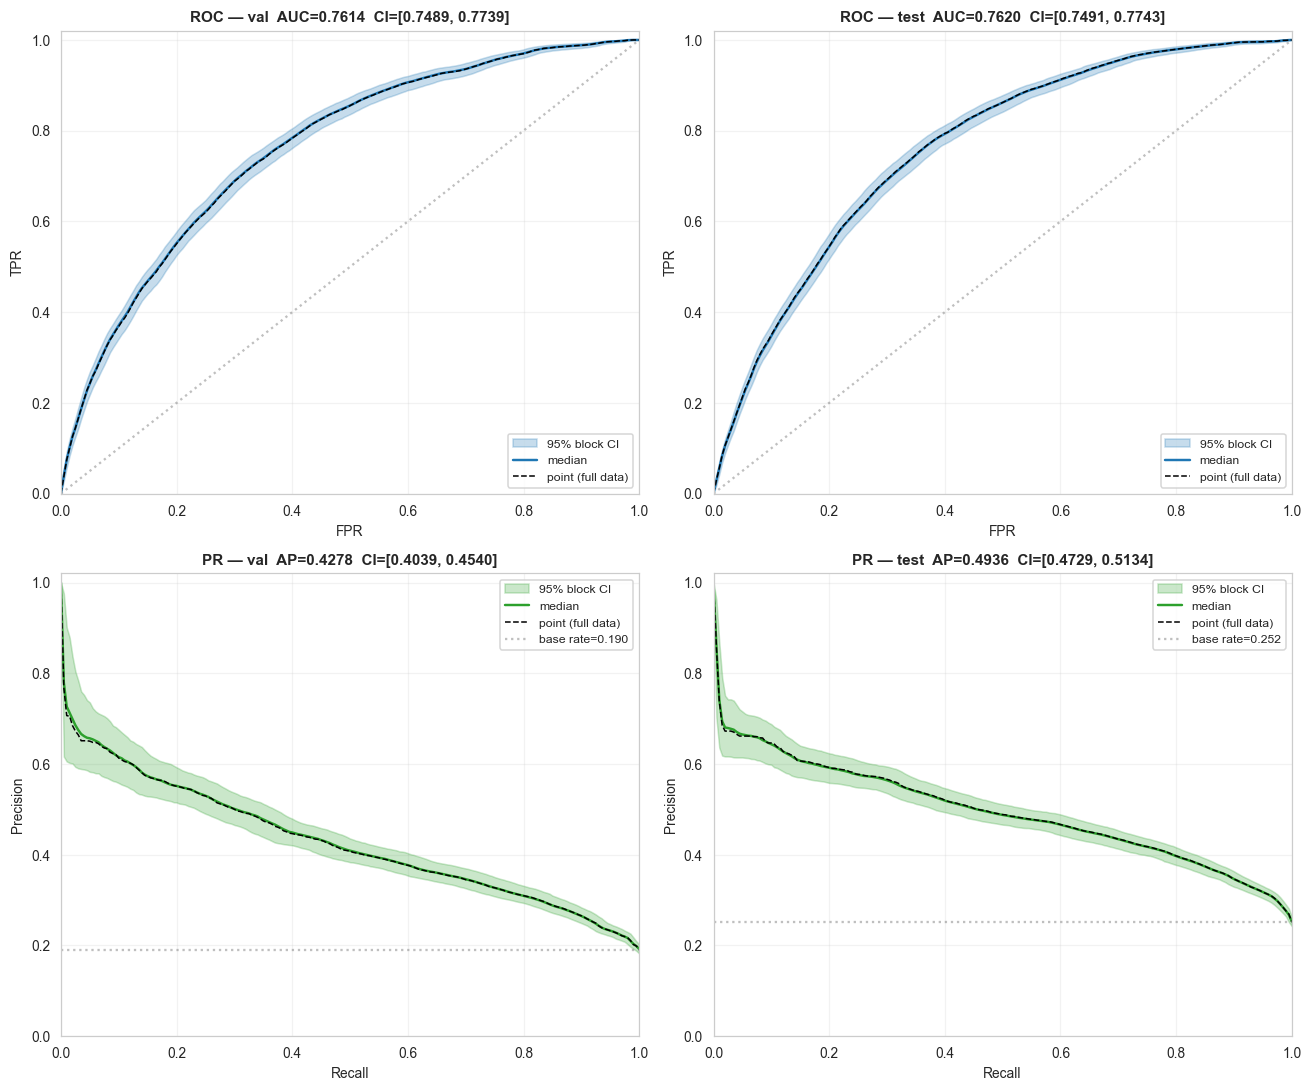

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\offline_roc_pr_1min.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
roc_results = {}
pr_results = {}
for col, (name, sub) in enumerate([('val', val), ('test', test)]):
    y = sub['y'].astype(int).to_numpy()
    p = sub['p'].astype(float).to_numpy()
    base = float(y.mean())

    roc = bootstrap_roc_curve(y, p, B=B_BOOTSTRAP, seed=0, block_size=BOOTSTRAP_BLOCK)
    pr = bootstrap_pr_curve(y, p, B=B_BOOTSTRAP, seed=0, block_size=BOOTSTRAP_BLOCK)
    roc_results[name] = roc
    pr_results[name] = pr

    ax = axes[0, col]
    ax.fill_between(roc.x_grid, roc.ci_low, roc.ci_high,
                    alpha=0.25, color='C0', label='95% block CI')
    ax.plot(roc.x_grid, roc.median, color='C0', linewidth=1.6, label='median')
    ax.plot(roc.x_grid, roc.point, color='k', linewidth=1.0,
            linestyle='--', label='point (full data)')
    ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
    ax.set(xlim=(0, 1), ylim=(0, 1.02), xlabel='FPR', ylabel='TPR',
           title=(f'ROC — {name}  AUC={roc.auc_median:.4f}  '
                  f'CI=[{roc.auc_ci_low:.4f}, {roc.auc_ci_high:.4f}]'))
    ax.legend(loc='lower right')

    ax = axes[1, col]
    ax.fill_between(pr.x_grid, pr.ci_low, pr.ci_high,
                    alpha=0.25, color='C2', label='95% block CI')
    ax.plot(pr.x_grid, pr.median, color='C2', linewidth=1.6, label='median')
    ax.plot(pr.x_grid, pr.point, color='k', linewidth=1.0,
            linestyle='--', label='point (full data)')
    ax.axhline(base, color='gray', linestyle=':', alpha=0.5,
               label=f'base rate={base:.3f}')
    ax.set(xlim=(0, 1), ylim=(0, 1.02), xlabel='Recall', ylabel='Precision',
           title=(f'PR — {name}  AP={pr.auc_median:.4f}  '
                  f'CI=[{pr.auc_ci_low:.4f}, {pr.auc_ci_high:.4f}]'))
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'offline_roc_pr_1min.png', bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "offline_roc_pr_1min.png"}')

## 4. Calibration curve

C:\Users\vitil\OneDrive\Desktop\barrier_classifier\venv\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


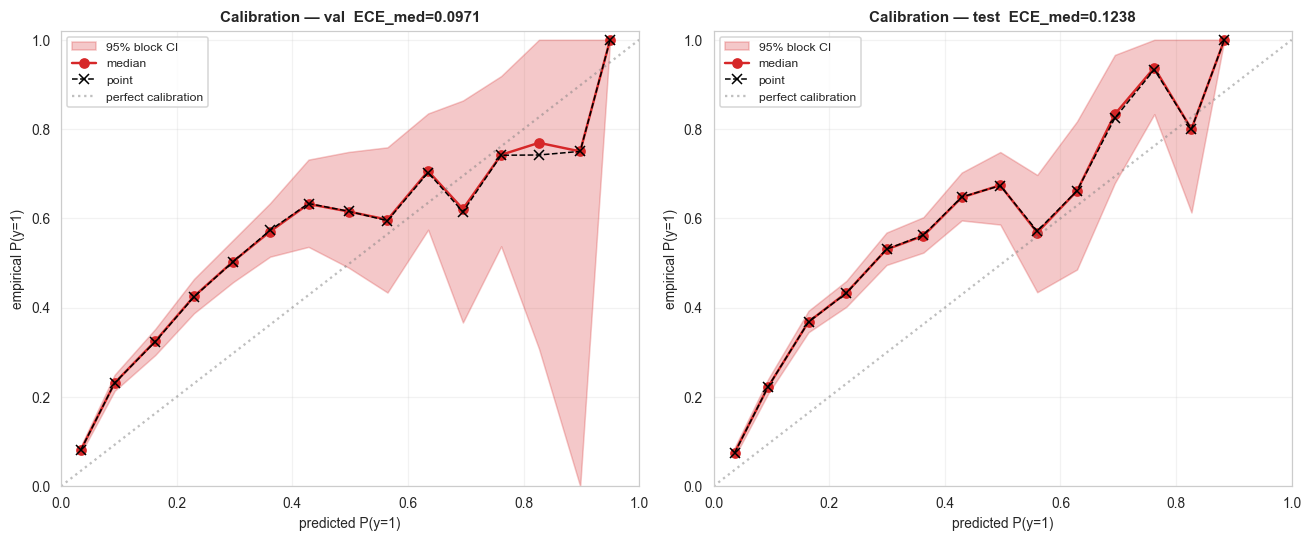

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\offline_calibration_1min.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
calibration_results = {}
for col, (name, sub) in enumerate([('val', val), ('test', test)]):
    y = sub['y'].astype(int).to_numpy()
    p = sub['p'].astype(float).to_numpy()
    cal = bootstrap_calibration_curve(
        y, p, B=B_BOOTSTRAP, seed=0, block_size=BOOTSTRAP_BLOCK, n_bins=15
    )
    calibration_results[name] = cal

    ax = axes[col]
    ax.fill_between(cal.x_grid, cal.ci_low, cal.ci_high, alpha=0.25,
                    color='C3', label='95% block CI')
    ax.plot(cal.x_grid, cal.median, color='C3', linewidth=1.6, marker='o', label='median')
    ax.plot(cal.x_grid, cal.point, color='k', linewidth=1.0,
            linestyle='--', marker='x', label='point')
    ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5,
            label='perfect calibration')
    ax.set(xlim=(0, 1), ylim=(0, 1.02),
           xlabel='predicted P(y=1)', ylabel='empirical P(y=1)',
           title=f'Calibration — {name}  ECE_med={cal.auc_median:.4f}')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'offline_calibration_1min.png', bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "offline_calibration_1min.png"}')

## 5. Score distribution by class and split

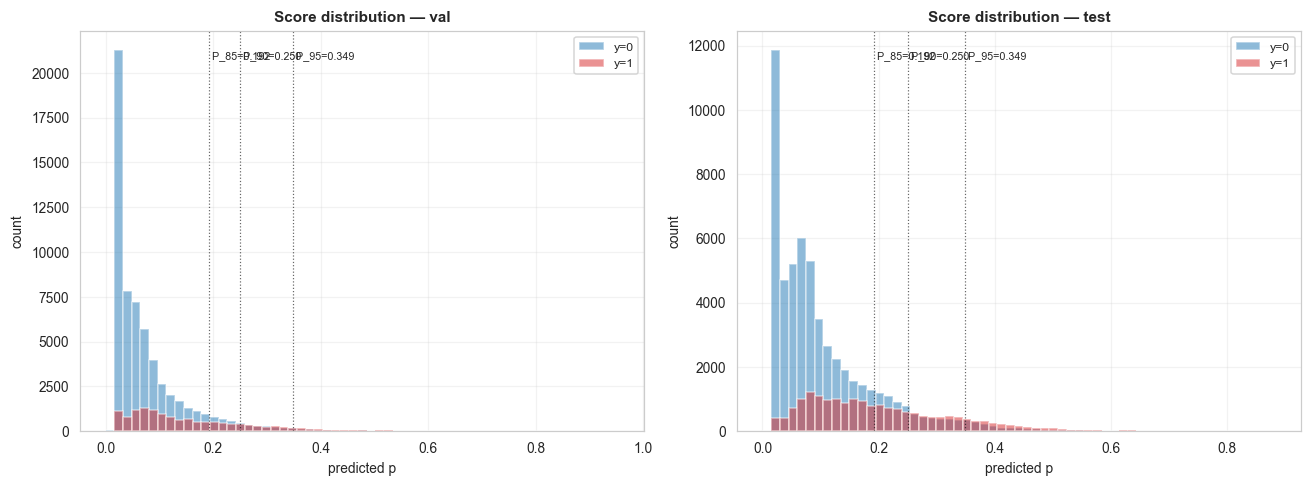

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\offline_score_dist_1min.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for col, (name, sub) in enumerate([('val', val), ('test', test)]):
    y = sub['y'].astype(int).to_numpy()
    p = sub['p'].astype(float).to_numpy()
    ax = axes[col]
    bins = np.linspace(0, max(0.6, p.max()), 60)
    ax.hist(p[y == 0], bins=bins, alpha=0.5, color='C0', label='y=0')
    ax.hist(p[y == 1], bins=bins, alpha=0.5, color='C3', label='y=1')
    for q in [0.85, 0.90, 0.95]:
        thresh = float(pred_meta['train_p_quantiles'][f'{q:.2f}'])
        ax.axvline(thresh, color='k', linestyle=':', alpha=0.6, linewidth=0.8)
        ax.text(thresh, ax.get_ylim()[1] * 0.95,
                f' P_{int(q*100)}={thresh:.3f}', fontsize=7, va='top')
    ax.set(xlabel='predicted p', ylabel='count',
           title=f'Score distribution — {name}')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'offline_score_dist_1min.png', bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "offline_score_dist_1min.png"}')

## 6. Threshold sweep — Net-EV with realized return

Net-EV = `mean(r_realized - cost)` over rows with `p >= threshold`. Cost
is `COST_PER_TRADE = 5 bp` from `src.strategy.baseline`. The threshold
grid is `train_p_quantiles` from training metadata — no val/test peek.

split  threshold  n_signals  signal_rate  precision  recall  net_per_trade_log  ev_total_log
  val     0.0179      69922       0.9371     0.2012  0.9921            -0.0005      -38.1195
  val     0.0191      66270       0.8882     0.2108  0.9850            -0.0005      -36.3721
  val     0.0606      37190       0.4984     0.3077  0.8070            -0.0006      -21.4386
  val     0.1017      21815       0.2924     0.3811  0.5862            -0.0006      -13.1955
  val     0.1221      17810       0.2387     0.4045  0.5081            -0.0006      -11.3310
  val     0.1512      13613       0.1824     0.4407  0.4231            -0.0006       -8.1694
  val     0.1919       9515       0.1275     0.4888  0.3280            -0.0005       -4.6450
  val     0.2498       5528       0.0741     0.5459  0.2128            -0.0004       -2.2979
  val     0.3491       2076       0.0278     0.6214  0.0910             0.0001        0.1200
 test     0.0179      73035       0.9788     0.2568  0.9973           

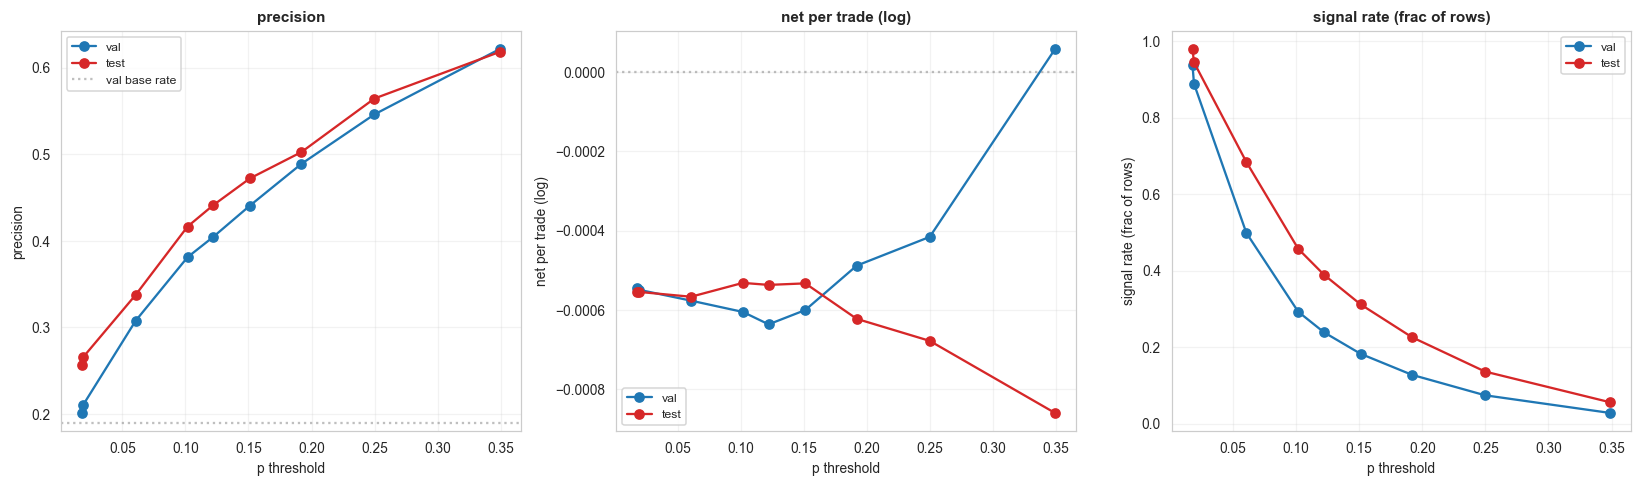

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\offline_threshold_sweep_1min.png


In [7]:
sweep_thresholds = sorted(
    {float(v) for v in pred_meta['train_p_quantiles'].values() if float(v) > 0}
)

def _sweep(sub, name):
    y = sub['y'].astype(int).to_numpy()
    p = sub['p'].astype(float).to_numpy()
    r = sub['r_realized'].astype(float).to_numpy()
    total_pos = int(y.sum())
    rows = []
    for t in sweep_thresholds:
        mask = p >= t
        n = int(mask.sum())
        if n == 0:
            continue
        r_mask = r[mask]
        r_mask_finite = r_mask[np.isfinite(r_mask)]
        if len(r_mask_finite) == 0:
            net_per_trade = float('nan')
            ev_total = float('nan')
        else:
            net_per_trade = float(np.mean(r_mask_finite) - COST_PER_TRADE)
            ev_total = float(np.sum(r_mask_finite - COST_PER_TRADE))
        rows.append({
            'split': name, 'threshold': t,
            'n_signals': n, 'signal_rate': n / len(sub),
            'precision': float(y[mask].mean()),
            'recall': float(y[mask].sum() / max(total_pos, 1)),
            'net_per_trade_log': net_per_trade,
            'ev_total_log': ev_total,
        })
    return pd.DataFrame(rows)

sweep_val = _sweep(val, 'val')
sweep_test = _sweep(test, 'test')
sweep_all = pd.concat([sweep_val, sweep_test], ignore_index=True)
print(sweep_all.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, ycol, ylabel in [
    (axes[0], 'precision', 'precision'),
    (axes[1], 'net_per_trade_log', 'net per trade (log)'),
    (axes[2], 'signal_rate', 'signal rate (frac of rows)'),
]:
    for nm, df_, color in [('val', sweep_val, 'C0'), ('test', sweep_test, 'C3')]:
        ax.plot(df_['threshold'], df_[ycol], marker='o', label=nm, color=color)
    ax.set(xlabel='p threshold', ylabel=ylabel, title=ylabel)
    if ycol == 'precision':
        ax.axhline(float(val['y'].mean()), color='gray', linestyle=':',
                   alpha=0.5, label='val base rate')
    if ycol == 'net_per_trade_log':
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'offline_threshold_sweep_1min.png', bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "offline_threshold_sweep_1min.png"}')

## 7. Rolling metrics over time — degradation diagnostic

Rolling windows: 101  columns: ['window_start', 'window_end', 'n_samples', 'n_pos', 'base_rate', 'roc_auc_point', 'roc_auc_ci_low', 'roc_auc_ci_high', 'pr_auc_point', 'pr_auc_ci_low', 'pr_auc_ci_high', 'brier_score_point', 'brier_score_ci_low', 'brier_score_ci_high', 'ece_10bin_point', 'ece_10bin_ci_low', 'ece_10bin_ci_high']
       window_start          window_end  n_samples  roc_auc_point  roc_auc_ci_low  roc_auc_ci_high  brier_score_point  brier_score_ci_low  brier_score_ci_high
2025-09-18 12:34:00 2025-09-23 12:34:00       7200         0.8085          0.7228           0.8705             0.0333              0.0227               0.0435
2025-09-19 12:34:00 2025-09-24 12:34:00       7200         0.8002          0.7373           0.8650             0.0420              0.0292               0.0555
2025-09-20 12:34:00 2025-09-25 12:34:00       7200         0.7495          0.6948           0.8074             0.0555              0.0427               0.0704
2025-09-21 12:34:00 2025-09-26 12:34

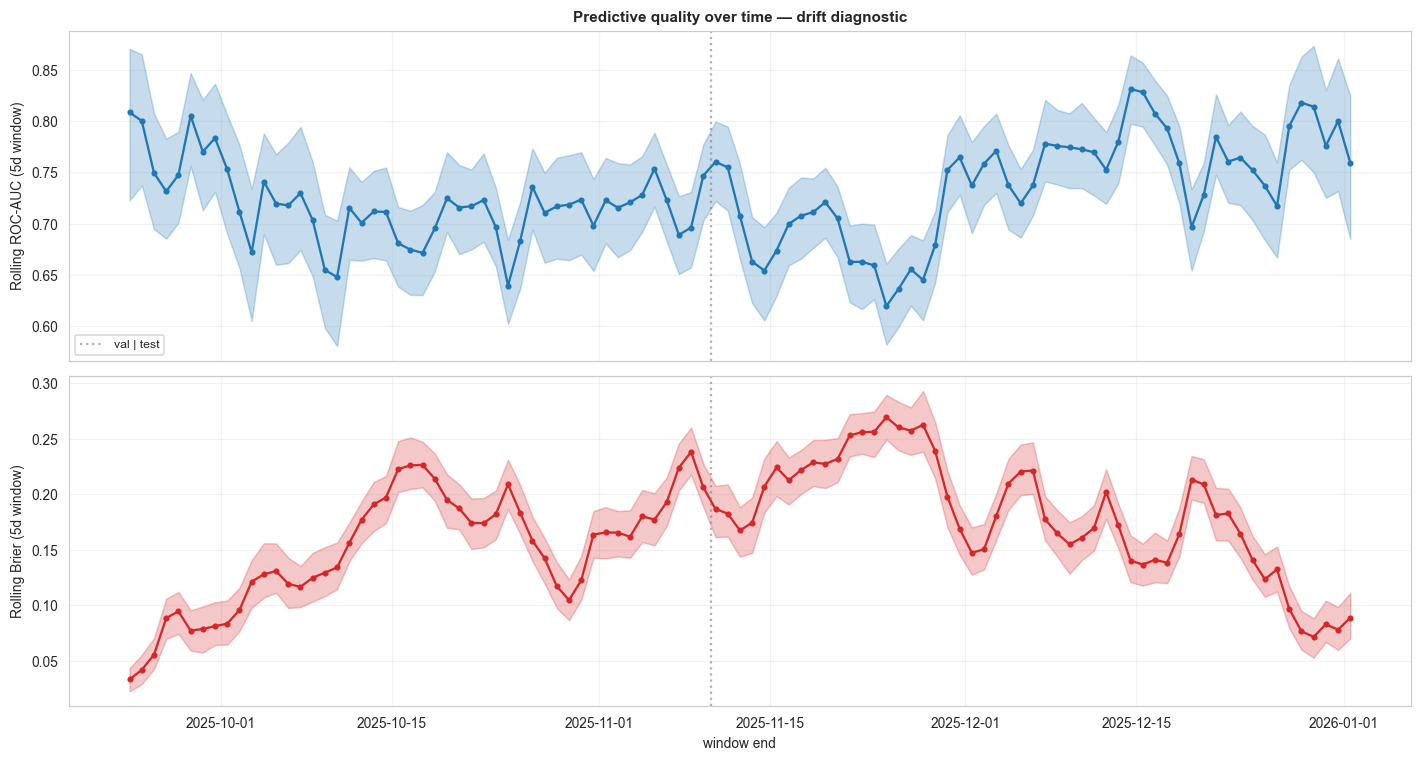

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\offline_rolling_metrics_1min.png


In [8]:
# rolling_metrics_with_ci filters by `split` column; we want the
# combined val+test stream so we relabel and pass that.
combined = cache.sort_values('ts').reset_index(drop=True).copy()
combined['ts'] = pd.to_datetime(combined['ts'])
combined_all = combined.assign(split='all')

# Pandas-time strings (the function uses df.set_index('ts').rolling(window))
ROLLING_WINDOW = '5D'  # 5 days
ROLLING_STEP = '1D'    # step every day

roll = rolling_metrics_with_ci(
    combined_all, split='all',
    window=ROLLING_WINDOW, step=ROLLING_STEP,
    B=200, seed=0, block_size=BOOTSTRAP_BLOCK,
    min_n=200, min_pos=20,
)
print(f'Rolling windows: {len(roll)}  columns: {list(roll.columns)}')
print(roll[['window_start', 'window_end', 'n_samples',
            'roc_auc_point', 'roc_auc_ci_low', 'roc_auc_ci_high',
            'brier_score_point', 'brier_score_ci_low', 'brier_score_ci_high']]
      .head(8).round(4).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
val_test_boundary = test['ts'].min()

ax = axes[0]
ax.fill_between(roll['window_end'], roll['roc_auc_ci_low'],
                roll['roc_auc_ci_high'], alpha=0.25, color='C0')
ax.plot(roll['window_end'], roll['roc_auc_point'],
        marker='o', color='C0', markersize=3)
ax.axvline(val_test_boundary, color='gray', linestyle=':',
           alpha=0.6, label='val | test')
ax.set(ylabel='Rolling ROC-AUC (5d window)',
       title='Predictive quality over time — drift diagnostic')
ax.legend()

ax = axes[1]
ax.fill_between(roll['window_end'], roll['brier_score_ci_low'],
                roll['brier_score_ci_high'], alpha=0.25, color='C3')
ax.plot(roll['window_end'], roll['brier_score_point'],
        marker='o', color='C3', markersize=3)
ax.axvline(val_test_boundary, color='gray', linestyle=':', alpha=0.6)
ax.set(ylabel='Rolling Brier (5d window)', xlabel='window end')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'offline_rolling_metrics_1min.png', bbox_inches='tight')
plt.show()
print(f'Saved: {PLOTS_DIR / "offline_rolling_metrics_1min.png"}')

## 8. Causal feature audit — re-run on the production feature list

In [9]:
audit = causal_feature_audit(feature_list)
print(f'Total features audited : {audit.n_features:,}')
print(f'Causal (__f__ / __h__) : {audit.n_causal:,}')
print(f'Suspect tokens         : {audit.n_suspect:,}')
print(f'Unmatched (no suffix)  : {len(audit.unmatched):,}')
if audit.suspect:
    print()
    print('Suspect feature names (first 20):')
    for f in audit.suspect[:20]:
        print(f'  {f}')
if audit.unmatched:
    print()
    print('Unmatched feature names (first 20):')
    for f in audit.unmatched[:20]:
        print(f'  {f}')

if not audit.passed:
    raise RuntimeError(
        f'Causal audit failed: {audit.n_suspect} suspect, '
        f'{len(audit.unmatched)} unmatched. Fix feature naming before shipping.'
    )
print()
print('OK: every production feature has __f__ or __h__ and no suspect tokens.')

Total features audited : 1,475
Causal (__f__ / __h__) : 1,475
Suspect tokens         : 0
Unmatched (no suffix)  : 0

OK: every production feature has __f__ or __h__ and no suspect tokens.


## 9. Virtual-ensemble uncertainty diagnostic

Decompose the VE predictions into predictive (mean), epistemic
(knowledge), and aleatoric components. The strategy in 05 uses the
*epistemic* component as a gate: "trade only when the model is
confident relative to other top-score rows". For that gate to be
useful, epistemic uncertainty must:

1. Vary across rows (have a non-trivial distribution).
2. Correlate with prediction quality.

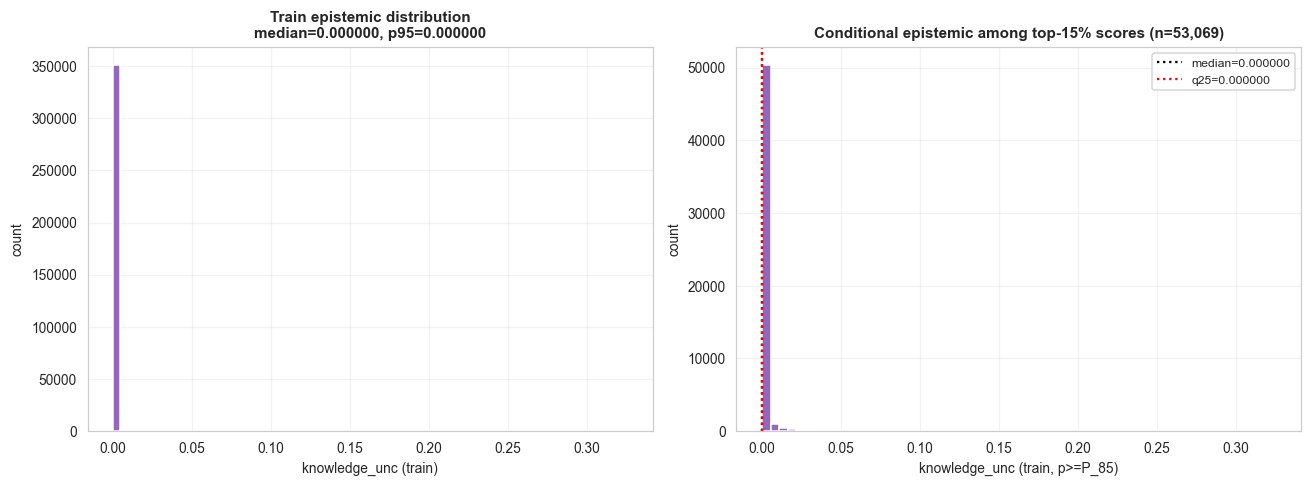

Precision vs epistemic-uncertainty quartile (val+test, p >= P_85):
                n  precision  median_p  median_unc
unc_bucket                                        
low         26360     0.4975    0.2702         0.0
Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\plots\offline_ve_uncertainty_1min.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(train_unc['knowledge_unc_train'], bins=80, color='C4')
ax.set(xlabel='knowledge_unc (train)', ylabel='count',
       title=(f'Train epistemic distribution\n'
              f'median={train_unc["knowledge_unc_train"].median():.6f}, '
              f'p95={train_unc["knowledge_unc_train"].quantile(0.95):.6f}'))

p85 = float(pred_meta['train_p_quantiles']['0.85'])
mask_top = train_unc['p_train'] >= p85
unc_top = train_unc.loc[mask_top, 'knowledge_unc_train']

ax = axes[1]
if len(unc_top) > 0 and unc_top.max() > 0:
    ax.hist(unc_top, bins=60, color='C4')
    ax.axvline(unc_top.median(), color='k', linestyle=':',
               label=f'median={unc_top.median():.6f}')
    ax.axvline(unc_top.quantile(0.25), color='r', linestyle=':',
               label=f'q25={unc_top.quantile(0.25):.6f}')
    ax.legend()
else:
    ax.text(0.5, 0.5,
            f'epistemic collapsed to ~0\nn(p>=P_85)={int(mask_top.sum())}',
            ha='center', va='center', transform=ax.transAxes)
ax.set(xlabel='knowledge_unc (train, p>=P_85)', ylabel='count',
       title=f'Conditional epistemic among top-15% scores (n={int(mask_top.sum()):,})')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'offline_ve_uncertainty_1min.png', bbox_inches='tight')
plt.show()

# Precision vs uncertainty bucket among val+test rows that pass the score gate.
# Use labels=False then map names so duplicates='drop' collapsing bins doesn't
# cause a "Bin labels must be one fewer than bin edges" error.
val_test_top = cache[cache['p'] >= p85].copy()
precision_by_bucket = pd.DataFrame()
if len(val_test_top) > 100 and val_test_top['knowledge_unc'].std() > 1e-12:
    bucket_idx = pd.qcut(
        val_test_top['knowledge_unc'], q=4, labels=False, duplicates='drop',
    )
    name_map = {0: 'low', 1: 'med-low', 2: 'med-high', 3: 'high'}
    val_test_top['unc_bucket'] = bucket_idx.map(name_map).fillna('unknown')
    precision_by_bucket = val_test_top.groupby('unc_bucket', dropna=False).agg(
        n=('y', 'size'),
        precision=('y', 'mean'),
        median_p=('p', 'median'),
        median_unc=('knowledge_unc', 'median'),
    ).round(4)
    # Reorder rows from low → high if all four buckets present
    order = [b for b in ['low', 'med-low', 'med-high', 'high'] if b in precision_by_bucket.index]
    precision_by_bucket = precision_by_bucket.loc[order]
    print('Precision vs epistemic-uncertainty quartile (val+test, p >= P_85):')
    print(precision_by_bucket.to_string())
else:
    print(f'Skipping uncertainty-quartile analysis: '
          f'n(p>=P_85)={len(val_test_top)}, '
          f'std(knowledge_unc)={val_test_top["knowledge_unc"].std() if len(val_test_top) else "n/a"}.')

print(f'Saved: {PLOTS_DIR / "offline_ve_uncertainty_1min.png"}')

## 10. Persist machine-readable summary

In [11]:
offline_summary = {
    'cadence': '1min',
    'M': int(M),
    'PHI': float(PHI),
    'block_bootstrap_size': BOOTSTRAP_BLOCK,
    'B_bootstrap': B_BOOTSTRAP,
    'splits': {
        'val':  {'n': int(len(val)),  'base_rate': float(val['y'].mean()),  'headline': val_headline},
        'test': {'n': int(len(test)), 'base_rate': float(test['y'].mean()), 'headline': test_headline},
    },
    'roc_pr_auc': {
        name: {
            'roc_auc_point': float(roc_results[name].auc_point),
            'roc_auc_median': float(roc_results[name].auc_median),
            'roc_auc_ci_low': float(roc_results[name].auc_ci_low),
            'roc_auc_ci_high': float(roc_results[name].auc_ci_high),
            'pr_auc_point': float(pr_results[name].auc_point),
            'pr_auc_median': float(pr_results[name].auc_median),
            'pr_auc_ci_low': float(pr_results[name].auc_ci_low),
            'pr_auc_ci_high': float(pr_results[name].auc_ci_high),
            'ece_point': float(calibration_results[name].auc_point),
            'ece_median': float(calibration_results[name].auc_median),
        }
        for name in ('val', 'test')
    },
    'threshold_sweep_train_p_quantiles': pred_meta['train_p_quantiles'],
    'threshold_sweep': sweep_all.to_dict(orient='records'),
    'rolling_metrics': {
        'window': ROLLING_WINDOW, 'step': ROLLING_STEP,
        'n_windows': int(len(roll)),
        'roc_auc_min': float(roll['roc_auc_point'].min()),
        'roc_auc_max': float(roll['roc_auc_point'].max()),
        'roc_auc_median': float(roll['roc_auc_point'].median()),
        'brier_min': float(roll['brier_score_point'].min()),
        'brier_max': float(roll['brier_score_point'].max()),
        'brier_median': float(roll['brier_score_point'].median()),
    },
    'causal_audit': {
        'n_features': audit.n_features,
        'n_causal': audit.n_causal,
        'n_suspect': audit.n_suspect,
        'passed': audit.passed,
    },
    've_uncertainty': {
        'train_knowledge_unc_median': float(train_unc['knowledge_unc_train'].median()),
        'train_knowledge_unc_p95': float(train_unc['knowledge_unc_train'].quantile(0.95)),
        'conditional_among_top_p85': {
            'n': int(mask_top.sum()),
            'median': float(unc_top.median()) if len(unc_top) else None,
            'q25': float(unc_top.quantile(0.25)) if len(unc_top) else None,
        },
        'precision_by_unc_bucket': (
            precision_by_bucket.reset_index().to_dict(orient='records')
            if len(precision_by_bucket) else []
        ),
    },
    'consumes': {
        'dataset': str(CACHE_PATH.relative_to(ROOT).as_posix()),
        'model_metadata': str(PRED_META_PATH.relative_to(ROOT).as_posix()),
        'best_iteration_by_val_logloss': pred_meta.get('best_iteration_by_val_logloss'),
        'tree_count': pred_meta.get('tree_count'),
        'git_sha': pred_meta.get('git_sha'),
    },
}

with open(OFFLINE_OUT, 'w') as f:
    json.dump(offline_summary, f, indent=2, default=str)
print(f'Saved: {OFFLINE_OUT}')
print()
print('=== Offline-evaluation summary ===')
print(f'Val  ROC-AUC : {val_headline["roc_auc"]["point"]:.4f}  '
      f'CI=[{val_headline["roc_auc"]["ci_low"]:.4f}, {val_headline["roc_auc"]["ci_high"]:.4f}]')
print(f'Test ROC-AUC : {test_headline["roc_auc"]["point"]:.4f}  '
      f'CI=[{test_headline["roc_auc"]["ci_low"]:.4f}, {test_headline["roc_auc"]["ci_high"]:.4f}]')
print(f'Rolling ROC-AUC : min={roll["roc_auc_point"].min():.4f}  '
      f'median={roll["roc_auc_point"].median():.4f}  '
      f'max={roll["roc_auc_point"].max():.4f}')
print(f'Rolling Brier   : min={roll["brier_score_point"].min():.4f}  '
      f'median={roll["brier_score_point"].median():.4f}  '
      f'max={roll["brier_score_point"].max():.4f}')
print(f'Causal audit : {audit.n_causal}/{audit.n_features} causal, {audit.n_suspect} suspect')
print(f'VE epistemic : train median='
      f'{train_unc["knowledge_unc_train"].median():.6f}, '
      f'top-15% median='
      f'{unc_top.median() if len(unc_top) else float("nan"):.6f}')

Saved: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\analytics\offline_evaluation_1min.json

=== Offline-evaluation summary ===
Val  ROC-AUC : 0.7608  CI=[0.7489, 0.7739]
Test ROC-AUC : 0.7630  CI=[0.7491, 0.7743]
Rolling ROC-AUC : min=0.6197  median=0.7231  max=0.8314
Rolling Brier   : min=0.0333  median=0.1697  max=0.2695
Causal audit : 1475/1475 causal, 0 suspect
VE epistemic : train median=0.000000, top-15% median=0.000000
